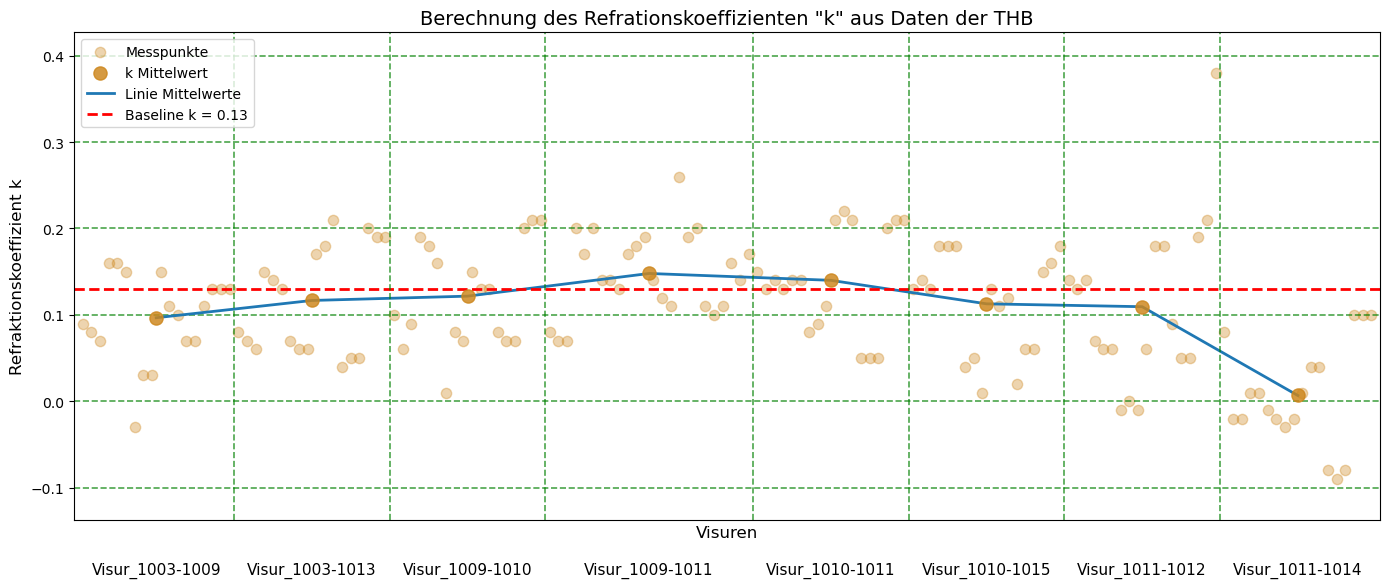

<Axes: title={'center': 'Berechnung des Refrationskoeffizienten "k" aus Daten der THB'}, xlabel='Visuren', ylabel='Refraktionskoeffizient k'>

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def scatterplot_k_abstand(df, y_col="Refraktionskoeff. k", label_col="ID Visur", center_value=0.13):
    df = df.copy()
    x_all = np.arange(len(df))
    y_all = df[y_col].astype(float).values
    visur_all = df[label_col].astype(str).values

    group_means = df.groupby(label_col)[y_col].mean().reset_index()
    visur_list = group_means[label_col].astype(str).tolist()
    mean_k = group_means[y_col].values.astype(float)

    # Position der Mittelwertpunkte
    x_means = []
    last_pos = 0
    for visur in visur_list:
        n_p = np.sum(visur_all == visur)
        x_means.append(last_pos + (n_p-1)/2 if n_p > 1 else last_pos)
        last_pos += n_p

    fig, ax = plt.subplots(figsize=(14, 6))
    pointcolor = "#cd861cd5"
    linecolor = "#1f78b4"
    gridcolor = "green"

    ax.scatter(x_all, y_all, color=pointcolor, s=55, alpha=0.35, zorder=1,label='Messpunkte')
    ax.scatter(x_means, mean_k, color=pointcolor, s=90, zorder=3, label='k Mittelwert')
    ax.plot(x_means, mean_k, color=linecolor, linewidth=2, zorder=2, label='Linie Mittelwerte')
    ax.axhline(center_value, color='red', linestyle='dashed', linewidth=2, label=f'Baseline k = {center_value}')

    ax.set_ylabel('Refraktionskoeffizient k', fontsize=12)
    ax.set_title('Berechnung des Refrationskoeffizienten "k" aus Daten der THB', fontsize=14)
    ax.set_xlabel('Visuren', fontsize=12)

    # Keine x-Ticks
    ax.xaxis.set_ticks([])

    # Grüne vertikale Linien (fein wie horizontale)
    last = 0
    for i, visur in enumerate(visur_list):
        n_p = np.sum(visur_all == visur)
        if i > 0:
            ax.axvline(last - 0.5, color=gridcolor, linestyle="--", alpha=0.7, linewidth=1.2)
        xpos = last + (n_p-1)/2 if n_p > 1 else last
        # Visur-Labels horizontal, ganz unten
        y_bottom = ax.get_ylim()[0]
        ax.annotate(visur, xy=(xpos, y_bottom), xytext=(0, -45),
                    textcoords='offset points',
                    ha='center', va='top', fontsize=11, rotation=0, color="black")
        last += n_p

    ax.yaxis.grid(True, linestyle="--", color=gridcolor, alpha=0.7, linewidth=1.2)
    ax.set_xlim(-1, len(df))
    y_min, y_max = np.min(y_all), np.max(y_all)
    ax.set_ylim(y_min - 0.1*(y_max-y_min), y_max + 0.1*(y_max-y_min))
    ax.legend()
    fig.tight_layout()
    plt.show()
    return ax

# Anwendung:
df = pd.read_csv("20251001_Kombi_All-Data.csv", sep=';')
scatterplot_k_abstand(df)
